# 1. Business Understanding

## 1.1 Бизнесийн асуудал

Энэхүү даалгаврын зорилго нь 31 хоногийн хугацаа хэтэрсэн
зээлдэгч 91 хоногийн хугацаа хэтрүүлэх эсэхийг таамаглах
Machine Learning model боловсруулах.

## 1.2 Target

Target variable нь `is_dpd_91` байна.

- `1` → зээлдэгч DPD91 болсон
- `0` → DPD91 болохоос өмнө төлөлт хийсэн

## 1.3 Prediction Point

`date_dpd_31`-ийг Prediction Point гэж үзнэ.

Өөрөөр хэлбэл model нь тухайн зээлдэгч DPD31 болсон
мөчид available байсан information дээр үндэслэн
DPD91 болох магадлалыг тооцно.

# 2. Data Understanding

## 2.1 Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILE_PATH = "../data/raw/Toki Data Scientist task.xlsx"

user_list = pd.read_excel(
    FILE_PATH,
    sheet_name="user_list",
    engine="openpyxl"
)

print("Shape:", user_list.shape)

Shape: (61200, 43)


## 2.2 Dataset-ийн бүтэц

In [12]:
print("Shape:", user_list.shape)

Shape: (61200, 43)


In [13]:
column_info = pd.DataFrame({
    "column": user_list.columns,
    "dtype": user_list.dtypes.astype(str)
})

column_info

,column,dtype
created_month,created_month,int64
date_dpd_31,date_dpd_31,datetime64[ns]
credit_id,credit_id,int64
limit_dpd31,limit_dpd31,float64
balance_dpd31,balance_dpd31,float64
limit_ondue,limit_ondue,int64
balance_ondue,balance_ondue,float64
invoiced_unpaid_amt,invoiced_unpaid_amt,float64
total_payment_amt,total_payment_amt,float64
ostype,ostype,float64


### 2.2.1 Feature-ийн үндсэн бүлгүүд

`user_list` dataset-ийн feature-үүдийг үндсэндээ credit/balance,
user characteristics, app and transaction behavior болон user activity
гэсэн бүлгүүдэд ангилж болно.

`date_dpd_31` нь DPD31 болсон яг огноог илэрхийлэх бөгөөд dataset-ийн
бусад feature-үүдийг энэ өдрийг Day 0 буюу cutoff point гэж үзэн
тодорхойлсон байна.

Иймээс эдгээр feature-үүдийг prediction point дээр available байсан
information гэж үзэж, дараагийн шатанд Data Leakage-ийн эрсдэлийг
нэмэлтээр шалгана.

In [14]:
missing_info = pd.DataFrame({
    "missing_count": user_list.isna().sum(),
    "missing_percent": user_list.isna().mean() * 100
})

missing_info = (
    missing_info
    .sort_values("missing_percent", ascending=False)
)

missing_info

,missing_count,missing_percent
avg_trx_amount_l7d,52655,86.037582
avg_trx_amount_l30d,41502,67.813725
avg_trx_amount_l60d,21144,34.549020
avg_trx_amount_l90d,20073,32.799020
app_recency_days,11522,18.826797
sessions_l7d,11522,18.826797
sessions_l30d,11522,18.826797
sessions_l60d,11522,18.826797
sessions_l90d,11522,18.826797
read_noti_l7d,11522,18.826797


In [15]:
missing_by_month = (
    user_list
    .assign(
        month=user_list["date_dpd_31"].dt.to_period("M").astype(str)
    )
    .groupby("month")
    .agg(
        total_records=("credit_id", "size"),
        missing_target=("is_dpd_91", lambda x: x.isna().sum()),
        missing_limit_dpd31=("limit_dpd31", lambda x: x.isna().sum()),
        missing_balance_dpd31=("balance_dpd31", lambda x: x.isna().sum()),
        missing_age=("age", lambda x: x.isna().sum()),
        missing_sessions_l30d=("sessions_l30d", lambda x: x.isna().sum()),
        missing_avg_trx_l7d=("avg_trx_amount_l7d", lambda x: x.isna().sum())
    )
    .reset_index()
)

missing_by_month

,month,total_records,missing_target,missing_limit_dpd31,missing_balance_dpd31,missing_age,missing_sessions_l30d,missing_avg_trx_l7d
0,2025-12,8796,139,0,0,139,774,7554
1,2026-01,7846,132,0,0,130,725,6788
2,2026-02,8733,103,0,0,102,558,7212
3,2026-03,9775,104,9775,9775,101,589,8263
4,2026-04,9263,93,0,0,93,543,7590
5,2026-05,8943,48,0,0,48,489,7404
6,2026-06,7844,7844,0,0,7844,7844,7844


## 2.3 Missing Values

Dataset-ийн feature-үүдийн missing rate харилцан адилгүй байна.
Зарим behavioral feature өндөр missing rate-тэй байгаа бол зарим
үндсэн feature-д missing утга байхгүй байна.

Missing утгуудын тархалт нь тодорхой time-based pattern-тэй байна.
Тухайлбал, 2026-06 сарын бүх observation-д `is_dpd_91` болон зарим
behavioral feature missing байгаа бол 2026-03 сарын бүх observation-д
`limit_dpd31` болон `balance_dpd31` missing байна.

Иймээс missing value-үүдийг шууд impute хийхээс өмнө үүссэн шалтгаан
болон бизнесийн утгыг шалгана.

In [16]:
trx_missing_check = user_list.groupby(
    user_list["avg_trx_amount_l7d"].isna()
).agg(
    avg_trx_amount_l7d_missing=("credit_id", "size"),
    trx_l7d_mean=("trx_l7d", "mean"),
    trx_l7d_median=("trx_l7d", "median"),
    trx_l7d_zero_rate=("trx_l7d", lambda x: (x == 0).mean() * 100)
)

trx_missing_check

,avg_trx_amount_l7d_missing,trx_l7d_mean,trx_l7d_median,trx_l7d_zero_rate
avg_trx_amount_l7d,,,,
False,8545,4.260503,3.0,0.000000
True,52655,0.000000,0.0,79.720824


In [17]:
sessions_missing_check = user_list.groupby(
    user_list["sessions_l30d"].isna()
).agg(
    records=("credit_id", "size"),
    trx_l30d_mean=("trx_l30d", "mean"),
    trx_l30d_zero_rate=("trx_l30d", lambda x: (x == 0).mean() * 100)
)

sessions_missing_check

,records,trx_l30d_mean,trx_l30d_zero_rate
sessions_l30d,,,
False,49678,3.368294,58.895286
True,11522,0.581906,13.591390


In [18]:
avg_trx_missing_nonzero = user_list[
    user_list["avg_trx_amount_l7d"].isna() &
    (user_list["trx_l7d"] > 0)
]

print("Missing avg_trx_amount_l7d but trx_l7d > 0:",
      len(avg_trx_missing_nonzero))

print("\nBy month:")
print(
    avg_trx_missing_nonzero["date_dpd_31"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

Missing avg_trx_amount_l7d but trx_l7d > 0: 0

By month:
Series([], Freq: M, Name: count, dtype: int64)


In [19]:
avg_trx_missing_nonzero[
    [
        "credit_id",
        "date_dpd_31",
        "trx_l7d",
        "avg_trx_amount_l7d"
    ]
].head(20)

,credit_id,date_dpd_31,trx_l7d,avg_trx_amount_l7d


### Missing pattern-ийн эхний ажиглалт

`avg_trx_amount_l7d` missing байгаа бүх observation-д `trx_l7d = 0`
байна. Иймээс уг missing value нь сүүлийн 7 хоногт transaction
хийгээгүйтэй холбоотой structural missing гэж үзэх үндэслэлтэй.

Иймээс preprocessing хийх үед эдгээр missing утгыг 0 болгон
боловсруулах боломжтой гэж үзэв.

Харин `sessions_l30d`-ийн missing pattern нь transaction inactivity-тэй
шууд нийцэхгүй байгаа тул уг feature-ийн missing утгыг тусад нь
авч үзнэ.

In [20]:
avg_trx_cols = [
    "avg_trx_amount_l7d",
    "avg_trx_amount_l30d",
    "avg_trx_amount_l60d",
    "avg_trx_amount_l90d"
]

for col in avg_trx_cols:
    window = col.replace("avg_trx_amount_", "")
    trx_col = f"trx_{window}"
    
    missing_mask = user_list[col].isna()
    
    print(f"\n{col}")
    print(f"Missing: {missing_mask.sum():,}")
    print(
        f"Missing + corresponding trx > 0: "
        f"{((missing_mask) & (user_list[trx_col] > 0)).sum():,}"
    )
    print(
        f"Missing + corresponding trx = 0: "
        f"{((missing_mask) & (user_list[trx_col] == 0)).sum():,}"
    )


avg_trx_amount_l7d
Missing: 52,655
Missing + corresponding trx > 0: 0
Missing + corresponding trx = 0: 41,977

avg_trx_amount_l30d
Missing: 41,502
Missing + corresponding trx > 0: 0
Missing + corresponding trx = 0: 30,824

avg_trx_amount_l60d
Missing: 21,144
Missing + corresponding trx > 0: 0
Missing + corresponding trx = 0: 10,466

avg_trx_amount_l90d
Missing: 20,073
Missing + corresponding trx > 0: 0
Missing + corresponding trx = 0: 9,395


In [21]:
trx_cols = [
    "trx_l7d",
    "trx_l30d",
    "trx_l60d",
    "trx_l90d"
]

for col in trx_cols:
    missing_mask = user_list[col].isna()

    print(f"\n{col}")
    print(f"Missing: {missing_mask.sum():,}")
    print(
        f"Missing + avg_trx_amount is also missing: "
        f"{(
            missing_mask &
            user_list[f'avg_trx_amount_{col.replace("trx_", "")}'].isna()
        ).sum():,}"
    )


trx_l7d
Missing: 10,678
Missing + avg_trx_amount is also missing: 10,678

trx_l30d
Missing: 10,678
Missing + avg_trx_amount is also missing: 10,678

trx_l60d
Missing: 10,678
Missing + avg_trx_amount is also missing: 10,678

trx_l90d
Missing: 10,678
Missing + avg_trx_amount is also missing: 10,678


In [22]:
trx_missing_by_month = (
    user_list[user_list["trx_l7d"].isna()]
    .assign(
        month=lambda df: df["date_dpd_31"].dt.to_period("M").astype(str)
    )
    .groupby("month")
    .size()
    .reset_index(name="missing_trx_l7d")
)

trx_missing_by_month

,month,missing_trx_l7d
0,2025-12,1032
1,2026-01,972
2,2026-02,330
3,2026-03,233
4,2026-04,163
5,2026-05,104
6,2026-06,7844


In [23]:
trx_missing_profile = (
    user_list[user_list["trx_l7d"].isna()]
    [
        [
            "trx_l7d",
            "trx_l30d",
            "trx_l60d",
            "trx_l90d",
            "trx_recency_l90d",
            "sessions_l7d",
            "sessions_l30d",
            "sessions_l60d",
            "sessions_l90d"
        ]
    ]
    .describe()
    .T
)

trx_missing_profile

,count,mean,std,min,25%,50%,75%,max
trx_l7d,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trx_l30d,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trx_l60d,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trx_l90d,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trx_recency_l90d,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sessions_l7d,1024.0,0.341797,0.914941,0.0,0.0,0.0,0.0,9.0
sessions_l30d,1024.0,1.845703,3.320251,0.0,0.0,1.0,2.0,38.0
sessions_l60d,1024.0,2.977539,4.215190,0.0,0.0,2.0,4.0,42.0
sessions_l90d,1024.0,2.536133,3.595460,0.0,0.0,1.0,4.0,41.0


In [24]:
trx_missing_profile

,count,mean,std,min,25%,50%,75%,max
trx_l7d,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trx_l30d,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trx_l60d,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trx_l90d,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trx_recency_l90d,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sessions_l7d,1024.0,0.341797,0.914941,0.0,0.0,0.0,0.0,9.0
sessions_l30d,1024.0,1.845703,3.320251,0.0,0.0,1.0,2.0,38.0
sessions_l60d,1024.0,2.977539,4.215190,0.0,0.0,2.0,4.0,42.0
sessions_l90d,1024.0,2.536133,3.595460,0.0,0.0,1.0,4.0,41.0


In [26]:
behavior_cols = [
    "trx_recency_l90d",
    "trx_l7d",
    "trx_l30d",
    "trx_l60d",
    "trx_l90d",
    "sessions_l7d",
    "sessions_l30d",
    "sessions_l60d",
    "sessions_l90d",
    "read_noti_l7d",
    "read_noti_l30d",
    "read_noti_l60d",
    "read_noti_l90d"
]

trx_missing_rows = user_list[user_list["trx_l7d"].isna()].copy()

behavior_missing_rate = (
    trx_missing_rows[behavior_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("missing_percent")
)

behavior_missing_rate

,missing_percent
trx_recency_l90d,100.000000
trx_l7d,100.000000
trx_l30d,100.000000
trx_l60d,100.000000
trx_l90d,100.000000
sessions_l7d,90.410189
sessions_l30d,90.410189
sessions_l60d,90.410189
sessions_l90d,90.410189
read_noti_l7d,90.410189


### Missing pattern-ийн ажиглалт

`trx_*` болон `avg_trx_amount_*` feature-үүдийн missing pattern
хоорондоо бүрэн нийцэж байна. `trx_*` missing байгаа бүх
observation-д corresponding `avg_trx_amount_*` мөн missing байна.

Мөн `trx_*` болон `trx_recency_l90d` feature-үүд хоорондоо ижил
missing pattern-тэй байна. Харин `sessions_*` болон `read_noti_*`
feature-үүдийн missing pattern бүрэн давхцахгүй байна.

Иймээс transaction-related missing утгуудыг нэг бүлэг болгон авч
үзэх боломжтой боловч бүх behavioral feature-ийг ижил аргаар
боловсруулахгүй.

In [27]:
duplicate_count = user_list.duplicated().sum()

credit_counts = user_list["credit_id"].value_counts()

print("Exact duplicate rows:", duplicate_count)
print("Total observations:", len(user_list))
print("Unique credit_id:", user_list["credit_id"].nunique())
print("Credits with multiple events:", (credit_counts > 1).sum())
print("Maximum events for one credit:", credit_counts.max())

Exact duplicate rows: 0
Total observations: 61200
Unique credit_id: 46516
Credits with multiple events: 12605
Maximum events for one credit: 6


In [28]:
credit_event_summary = (
    user_list
    .groupby("credit_id")
    .agg(
        event_count=("date_dpd_31", "size"),
        first_dpd31=("date_dpd_31", "min"),
        last_dpd31=("date_dpd_31", "max")
    )
    .reset_index()
)

credit_event_summary["event_span_days"] = (
    credit_event_summary["last_dpd31"]
    - credit_event_summary["first_dpd31"]
).dt.days

credit_event_summary.describe()

,credit_id,event_count,first_dpd31,last_dpd31,event_span_days
count,4.651600e+04,46516.000000,46516,46516,46516.000000
mean,2.282606e+06,1.315676,2026-03-03 16:31:40.765327872,2026-03-30 00:48:10.153925376,26.344785
min,2.000111e+06,1.000000,2025-12-16 00:00:00,2025-12-16 00:00:00,0.000000
25%,2.150116e+06,1.000000,2026-01-15 00:00:00,2026-02-15 00:00:00,0.000000
50%,2.266380e+06,1.000000,2026-02-15 00:00:00,2026-04-15 00:00:00,0.000000
75%,2.420579e+06,2.000000,2026-04-15 00:00:00,2026-05-16 00:00:00,59.000000
max,2.623202e+06,6.000000,2026-06-15 00:00:00,2026-06-15 00:00:00,181.000000
std,1.611693e+05,0.559145,NaN,NaN,47.683065


In [29]:
event_distribution = (
    credit_counts
    .value_counts()
    .sort_index()
    .rename_axis("number_of_events")
    .reset_index(name="number_of_credits")
)

event_distribution

,number_of_events,number_of_credits
0,1,33911
1,2,10685
2,3,1769
3,4,144
4,5,6
5,6,1


In [30]:
tmp = user_list.sort_values(
    ["credit_id", "date_dpd_31"]
).copy()

tmp["days_since_previous_event"] = (
    tmp.groupby("credit_id")["date_dpd_31"]
    .diff()
    .dt.days
)

tmp["days_since_previous_event"].describe()

count    14684.000000
mean        83.455053
std         33.475044
min         28.000000
25%         61.000000
50%         89.000000
75%         92.000000
max        181.000000
Name: days_since_previous_event, dtype: float64

In [31]:
credit_event_summary.describe()

,credit_id,event_count,first_dpd31,last_dpd31,event_span_days
count,4.651600e+04,46516.000000,46516,46516,46516.000000
mean,2.282606e+06,1.315676,2026-03-03 16:31:40.765327872,2026-03-30 00:48:10.153925376,26.344785
min,2.000111e+06,1.000000,2025-12-16 00:00:00,2025-12-16 00:00:00,0.000000
25%,2.150116e+06,1.000000,2026-01-15 00:00:00,2026-02-15 00:00:00,0.000000
50%,2.266380e+06,1.000000,2026-02-15 00:00:00,2026-04-15 00:00:00,0.000000
75%,2.420579e+06,2.000000,2026-04-15 00:00:00,2026-05-16 00:00:00,59.000000
max,2.623202e+06,6.000000,2026-06-15 00:00:00,2026-06-15 00:00:00,181.000000
std,1.611693e+05,0.559145,NaN,NaN,47.683065


In [32]:
event_distribution

,number_of_events,number_of_credits
0,1,33911
1,2,10685
2,3,1769
3,4,144
4,5,6
5,6,1


In [33]:
tmp["days_since_previous_event"].describe()

count    14684.000000
mean        83.455053
std         33.475044
min         28.000000
25%         61.000000
50%         89.000000
75%         92.000000
max        181.000000
Name: days_since_previous_event, dtype: float64

# 3. Temporal & Data Leakage Audit

Model нь `date_dpd_31` буюу DPD31 болсон мөчид available байсан
information дээр үндэслэн `is_dpd_91`-ийг таамаглах ёстой.

Иймээс feature бүрийг prediction point-той уялдуулан шалгаж,
future information болон identifier-үүдийг model-д оруулахгүй.

`data_description`-ийн дагуу `user_list`-ийн бусад feature-үүд
`date_dpd_31`-ийг Day 0 буюу cutoff point гэж үзэн тодорхойлогдсон.

In [34]:
description_df = pd.read_excel(
    FILE_PATH,
    sheet_name="data_description",
    engine="openpyxl"
)

description_df.head()

,Sheet Name,Columns,Column Description
0,payment,created_month,Month
1,NaN,credit_id,Unique identifier for the loan account/credit ...
2,NaN,total_paid_amt,Total paid amount MNT
3,overdue,created_month,Month
4,NaN,credit_id,Unique identifier for the loan account/credit ...


In [35]:
description_df.columns

Index(['Sheet Name', 'Columns', 'Column Description'], dtype='object')

In [36]:
description_df["sheet_group"] = description_df["Sheet Name"].ffill()

description_df[["sheet_group", "Columns", "Column Description"]]

,sheet_group,Columns,Column Description
0,payment,created_month,Month
1,payment,credit_id,Unique identifier for the loan account/credit ...
2,payment,total_paid_amt,Total paid amount MNT
3,overdue,created_month,Month
4,overdue,credit_id,Unique identifier for the loan account/credit ...
...,...,...,...
92,user_list,number_change_cnt_l30d,Count of SIM card or device hardware identifie...
93,user_list,number_change_cnt_l60d,Count of SIM card or device hardware identifie...
94,user_list,number_change_cnt_l90d,Count of SIM card or device hardware identifie...
95,user_list,number_change_cnt,Lifetime count of SIM card or device hardware ...


In [37]:
description_df.groupby("sheet_group").size()

sheet_group
balance       9
overdue      42
payment       3
user_list    43
dtype: int64

In [38]:
description_df["sheet_group"].value_counts()

sheet_group
user_list    43
overdue      42
balance       9
payment       3
Name: count, dtype: int64

In [39]:
user_features = description_df[
    description_df["sheet_group"] == "user_list"
].copy()

user_features[
    ["Columns", "Column Description"]
]

,Columns,Column Description
54,created_month,Month
55,date_dpd_31,Exact date when the borrower's delinquency rea...
56,credit_id,Unique identifier for the loan account/credit ...
57,limit_dpd31,Credit line limit at the moment DPD 31 was tri...
58,balance_dpd31,Outstanding balance utilized at the moment DPD...
59,limit_ondue,Credit line limit on the payment due date
60,balance_ondue,Outstanding balance utilized on the payment du...
61,invoiced_unpaid_amt,Total billed/requested invoice amount that rem...
62,total_payment_amt,Total payment amount successfully received dur...
63,ostype,"Smartphone operating system (e.g., iOS, Android)"


In [40]:
feature_audit = user_features[
    ["Columns", "Column Description"]
].copy()

feature_audit["role"] = "Candidate Feature"
feature_audit["leakage_status"] = "To Review"

feature_audit.loc[
    feature_audit["Columns"] == "credit_id",
    ["role", "leakage_status"]
] = ["Exclude", "Identifier"]

feature_audit.loc[
    feature_audit["Columns"] == "date_dpd_31",
    ["role", "leakage_status"]
] = ["Exclude", "Prediction Point"]

feature_audit.loc[
    feature_audit["Columns"] == "is_dpd_91",
    ["role", "leakage_status"]
] = ["Target", "Target Variable"]

feature_audit

,Columns,Column Description,role,leakage_status
54,created_month,Month,Candidate Feature,To Review
55,date_dpd_31,Exact date when the borrower's delinquency rea...,Exclude,Prediction Point
56,credit_id,Unique identifier for the loan account/credit ...,Exclude,Identifier
57,limit_dpd31,Credit line limit at the moment DPD 31 was tri...,Candidate Feature,To Review
58,balance_dpd31,Outstanding balance utilized at the moment DPD...,Candidate Feature,To Review
59,limit_ondue,Credit line limit on the payment due date,Candidate Feature,To Review
60,balance_ondue,Outstanding balance utilized on the payment du...,Candidate Feature,To Review
61,invoiced_unpaid_amt,Total billed/requested invoice amount that rem...,Candidate Feature,To Review
62,total_payment_amt,Total payment amount successfully received dur...,Candidate Feature,To Review
63,ostype,"Smartphone operating system (e.g., iOS, Android)",Candidate Feature,To Review


In [41]:
feature_audit = user_features[
    ["Columns", "Column Description"]
].copy()

feature_audit["role"] = "Candidate Feature"
feature_audit["leakage_status"] = "Potentially safe"

# Excluded columns
feature_audit.loc[
    feature_audit["Columns"] == "credit_id",
    ["role", "leakage_status"]
] = ["Exclude", "Identifier"]

feature_audit.loc[
    feature_audit["Columns"] == "date_dpd_31",
    ["role", "leakage_status"]
] = ["Exclude", "Prediction Point"]

feature_audit.loc[
    feature_audit["Columns"] == "is_dpd_91",
    ["role", "leakage_status"]
] = ["Target", "Target Variable"]

# Features requiring additional review
feature_audit.loc[
    feature_audit["Columns"].isin(
        ["created_month", "total_payment_amt"]
    ),
    "leakage_status"
] = "Needs temporal review"

feature_audit

,Columns,Column Description,role,leakage_status
54,created_month,Month,Candidate Feature,Needs temporal review
55,date_dpd_31,Exact date when the borrower's delinquency rea...,Exclude,Prediction Point
56,credit_id,Unique identifier for the loan account/credit ...,Exclude,Identifier
57,limit_dpd31,Credit line limit at the moment DPD 31 was tri...,Candidate Feature,Potentially safe
58,balance_dpd31,Outstanding balance utilized at the moment DPD...,Candidate Feature,Potentially safe
59,limit_ondue,Credit line limit on the payment due date,Candidate Feature,Potentially safe
60,balance_ondue,Outstanding balance utilized on the payment du...,Candidate Feature,Potentially safe
61,invoiced_unpaid_amt,Total billed/requested invoice amount that rem...,Candidate Feature,Potentially safe
62,total_payment_amt,Total payment amount successfully received dur...,Candidate Feature,Needs temporal review
63,ostype,"Smartphone operating system (e.g., iOS, Android)",Candidate Feature,Potentially safe


In [42]:
feature_audit.groupby(
    ["role", "leakage_status"]
).size()

role               leakage_status       
Candidate Feature  Needs temporal review     2
                   Potentially safe         38
Exclude            Identifier                1
                   Prediction Point          1
Target             Target Variable           1
dtype: int64

### Feature availability-ийн эхний үнэлгээ

`user_list`-ийн feature-үүдийг `date_dpd_31`-ийг prediction point
болгон авч үзэн шалгав.

`credit_id` нь identifier, `date_dpd_31` нь prediction point,
`is_dpd_91` нь target тул model-ийн input-д оруулахгүй.

Historical behavioral болон user-level feature-үүдийг candidate feature
гэж үзэв. Харин `created_month` болон `total_payment_amt` нь хугацааны
хамаарлыг нэмэлтээр шалгах шаардлагатай гэж үзэв.

`payment`, `overdue`, `balance` sheet-үүдийг baseline model-д шууд
merge хийхгүй бөгөөд ашиглах тохиолдолд prediction point-оос өмнөх
мэдээллээр feature үүсгэнэ.

In [43]:
payment_df = pd.read_excel(
    FILE_PATH,
    sheet_name="payment",
    engine="openpyxl"
)

payment_df["created_month"].min(), payment_df["created_month"].max()

(np.int64(202407), np.int64(202606))

In [45]:
feature_audit.loc[
    feature_audit["Columns"] == "created_month",
    ["role", "leakage_status"]
] = ["Exclude", "Time identifier"]

feature_audit.loc[
    feature_audit["Columns"] == "total_payment_amt",
    "leakage_status"
] = "Needs temporal review"

In [46]:
feature_audit[
    ["Columns", "role", "leakage_status"]
]

,Columns,role,leakage_status
54,created_month,Exclude,Time identifier
55,date_dpd_31,Exclude,Prediction Point
56,credit_id,Exclude,Identifier
57,limit_dpd31,Candidate Feature,Potentially safe
58,balance_dpd31,Candidate Feature,Potentially safe
59,limit_ondue,Candidate Feature,Potentially safe
60,balance_ondue,Candidate Feature,Potentially safe
61,invoiced_unpaid_amt,Candidate Feature,Potentially safe
62,total_payment_amt,Candidate Feature,Needs temporal review
63,ostype,Candidate Feature,Potentially safe


In [47]:
candidate_features = feature_audit.loc[
    feature_audit["role"] == "Candidate Feature",
    "Columns"
].tolist()

candidate_features

['limit_dpd31',
 'balance_dpd31',
 'limit_ondue',
 'balance_ondue',
 'invoiced_unpaid_amt',
 'total_payment_amt',
 'ostype',
 'liveness_cnt',
 'liveness_success_cnt',
 'liveness_forgetful_cnt',
 'liveness_fail_cnt',
 'user_tenure',
 'profile_changed_since',
 'has_changed_phone',
 'gender',
 'age',
 'app_recency_days',
 'trx_recency_l90d',
 'trx_l7d',
 'trx_l30d',
 'trx_l60d',
 'trx_l90d',
 'avg_trx_amount_l7d',
 'avg_trx_amount_l30d',
 'avg_trx_amount_l60d',
 'avg_trx_amount_l90d',
 'sessions_l7d',
 'sessions_l30d',
 'sessions_l60d',
 'sessions_l90d',
 'read_noti_l7d',
 'read_noti_l30d',
 'read_noti_l60d',
 'read_noti_l90d',
 'is_unitel',
 'number_change_cnt_l30d',
 'number_change_cnt_l60d',
 'number_change_cnt_l90d',
 'number_change_cnt']

In [48]:
final_candidate_features = [
    col for col in candidate_features
    if col != "total_payment_amt"
]

len(final_candidate_features), final_candidate_features

(38,
 ['limit_dpd31',
  'balance_dpd31',
  'limit_ondue',
  'balance_ondue',
  'invoiced_unpaid_amt',
  'ostype',
  'liveness_cnt',
  'liveness_success_cnt',
  'liveness_forgetful_cnt',
  'liveness_fail_cnt',
  'user_tenure',
  'profile_changed_since',
  'has_changed_phone',
  'gender',
  'age',
  'app_recency_days',
  'trx_recency_l90d',
  'trx_l7d',
  'trx_l30d',
  'trx_l60d',
  'trx_l90d',
  'avg_trx_amount_l7d',
  'avg_trx_amount_l30d',
  'avg_trx_amount_l60d',
  'avg_trx_amount_l90d',
  'sessions_l7d',
  'sessions_l30d',
  'sessions_l60d',
  'sessions_l90d',
  'read_noti_l7d',
  'read_noti_l30d',
  'read_noti_l60d',
  'read_noti_l90d',
  'is_unitel',
  'number_change_cnt_l30d',
  'number_change_cnt_l60d',
  'number_change_cnt_l90d',
  'number_change_cnt'])

### Leakage audit-ийн шийдвэр

`credit_id` нь identifier, `date_dpd_31` нь prediction point,
`is_dpd_91` нь target тул model input-оос хасав.

`created_month` нь prediction point-той давхардсан time information
өгөх тул baseline model-д ашиглахгүй.

`total_payment_amt`-ийн reporting period тодорхой бус байгаа тул
temporal leakage үүсэх эсэхийг бүрэн баталгаажуулах хүртэл baseline
model-д ашиглахгүй.

Бусад `user_list` feature-үүд нь `date_dpd_31`-ийг cutoff point
гэж үзсэн historical эсвэл prediction-point information тул
candidate feature гэж үзэв.

# 4. Target Analysis

Энэ хэсэгт target variable-ийн тархалт, missing target болон
хугацааны явц дахь target-ийн өөрчлөлтийг шалгана.

Мөн нэг `credit_id` олон DPD31 event-тэй тохиолдолд target-ийн
тогтвортой байдлыг шалгаж, model validation-ийн стратегид
анхаарах шаардлагатай эсэхийг тодорхойлно.

In [49]:
target = "is_dpd_91"

print("Total observations:", len(user_list))
print("Missing target:", user_list[target].isna().sum())
print("Labeled observations:", user_list[target].notna().sum())

user_list[target].value_counts(dropna=False)

Total observations: 61200
Missing target: 8463
Labeled observations: 52737


is_dpd_91
0.0    36064
1.0    16673
NaN     8463
Name: count, dtype: int64

In [50]:
target_dist = (
    user_list.loc[user_list[target].notna(), target]
    .value_counts()
    .sort_index()
    .rename(index={0.0: "0 - Not DPD91", 1.0: "1 - DPD91"})
    .to_frame("count")
)

target_dist["percent"] = (
    target_dist["count"]
    / target_dist["count"].sum()
    * 100
)

target_dist

,count,percent
is_dpd_91,,
0 - Not DPD91,36064,68.384626
1 - DPD91,16673,31.615374


In [51]:
monthly_target = (
    user_list[user_list[target].notna()]
    .assign(
        month=lambda df: df["date_dpd_31"].dt.to_period("M").astype(str)
    )
    .groupby("month")
    .agg(
        records=(target, "size"),
        dpd91_count=(target, "sum"),
        dpd91_rate=(target, "mean")
    )
    .reset_index()
)

monthly_target["dpd91_rate"] *= 100

monthly_target

,month,records,dpd91_count,dpd91_rate
0,2025-12,8657,2673.0,30.876747
1,2026-01,7714,2376.0,30.801141
2,2026-02,8630,2960.0,34.298957
3,2026-03,9671,3176.0,32.840451
4,2026-04,9170,2945.0,32.115594
5,2026-05,8895,2543.0,28.589095


In [52]:
target_missing_by_month = (
    user_list
    .assign(
        month=lambda df: df["date_dpd_31"].dt.to_period("M").astype(str)
    )
    .groupby("month")
    .agg(
        total_records=(target, "size"),
        missing_target=(target, lambda x: x.isna().sum()),
        labeled_records=(target, lambda x: x.notna().sum())
    )
    .reset_index()
)

target_missing_by_month

,month,total_records,missing_target,labeled_records
0,2025-12,8796,139,8657
1,2026-01,7846,132,7714
2,2026-02,8733,103,8630
3,2026-03,9775,104,9671
4,2026-04,9263,93,9170
5,2026-05,8943,48,8895
6,2026-06,7844,7844,0


In [53]:
target_consistency = (
    user_list[user_list[target].notna()]
    .groupby("credit_id")[target]
    .nunique()
)

print(
    "Credits with multiple labeled target values:",
    (target_consistency > 1).sum()
)

print(
    "Credits with multiple labeled events:",
    (target_consistency.index.isin(
        user_list.loc[user_list[target].notna(), "credit_id"]
        .value_counts()
        .loc[lambda x: x > 1]
        .index
    )).sum()
)

Credits with multiple labeled target values: 3374
Credits with multiple labeled events: 9833


In [54]:
inconsistent_credit_ids = target_consistency[
    target_consistency > 1
].index

user_list[
    user_list["credit_id"].isin(inconsistent_credit_ids)
][
    ["credit_id", "date_dpd_31", "is_dpd_91"]
].sort_values(
    ["credit_id", "date_dpd_31"]
).head(20)

,credit_id,date_dpd_31,is_dpd_91
34868,2000146,2025-12-16,0.0
6889,2000146,2026-02-15,1.0
7478,2000924,2025-12-16,0.0
8552,2000924,2026-03-18,1.0
36712,2000937,2026-02-15,0.0
23346,2000937,2026-04-15,1.0
22705,2001092,2026-02-15,0.0
33560,2001092,2026-04-15,1.0
14254,2001127,2026-01-15,0.0
33561,2001127,2026-04-15,1.0


# 5. Exploratory Data Analysis

Энэ хэсэгт feature-үүдийн тархалт, missing value, outlier болон
target-той хамаарлыг шалгана.

EDA-ийн зорилго нь model-д оруулах feature-үүдийн шинж чанарыг
ойлгож, шаардлагатай preprocessing болон feature engineering-ийн
шийдвэрүүдийг data дээр үндэслэн гаргах юм.

In [55]:
categorical_features = [
    "ostype",
    "gender",
    "has_changed_phone",
    "is_unitel"
]

numeric_features = [
    col for col in final_candidate_features
    if col not in categorical_features
]

print("Categorical features:", len(categorical_features))
print("Numeric features:", len(numeric_features))

Categorical features: 4
Numeric features: 34


In [56]:
eda_df = user_list[
    final_candidate_features + ["is_dpd_91"]
].copy()

numeric_target_summary = (
    eda_df
    .groupby("is_dpd_91")[numeric_features]
    .median()
    .T
)

numeric_target_summary.columns = [
    "Not_DPD91",
    "DPD91"
]

numeric_target_summary["difference_%"] = (
    (
        numeric_target_summary["DPD91"]
        - numeric_target_summary["Not_DPD91"]
    )
    / numeric_target_summary["Not_DPD91"].replace(0, np.nan)
    * 100
)

numeric_target_summary.sort_values(
    "difference_%",
    key=lambda x: x.abs(),
    ascending=False
)

,Not_DPD91,DPD91,difference_%
app_recency_days,4.0000,8.000000,100.000000
read_noti_l90d,1.0000,2.000000,100.000000
sessions_l30d,3.0000,2.000000,-33.333333
trx_l60d,3.0000,2.000000,-33.333333
liveness_cnt,3.0000,4.000000,33.333333
trx_recency_l90d,38.0000,47.000000,23.684211
avg_trx_amount_l30d,11862.6646,9138.888889,-22.960910
avg_trx_amount_l90d,27960.0000,32000.000000,14.449213
sessions_l60d,7.0000,6.000000,-14.285714
avg_trx_amount_l7d,6600.1000,5833.333333,-11.617501


In [57]:
selected_eda_features = [
    "app_recency_days",
    "trx_recency_l90d",
    "sessions_l30d",
    "trx_l30d",
    "balance_dpd31",
    "invoiced_unpaid_amt"
]

eda_distribution = (
    user_list[user_list["is_dpd_91"].notna()]
    .groupby("is_dpd_91")[selected_eda_features]
    .agg(["count", "median", "mean", "std"])
)

eda_distribution

app_recency_days                              trx_recency_l90d  \
                     count median       mean        std            count   
is_dpd_91                                                                  
0.0                  34213    4.0  14.221436  18.984809            34732   
1.0                  15461    8.0  18.294354  20.822044            15786   

                                       sessions_l30d         ...  trx_l30d  \
          median       mean        std         count median  ...      mean   
is_dpd_91                                                    ...             
0.0         38.0  35.432109  23.166120         34213    3.0  ...  3.536163   
1.0         47.0  40.256050  22.224844         15461    2.0  ...  2.669834   

                     balance_dpd31                                           \
                 std         count     median           mean            std   
is_dpd_91                                                                     
0.0         9.242244         29569  249363.09  255080.280245  160606.773058   
1.0        10.580794         13497  261488.65  265260.259056  168812.841483   

          invoiced_unpaid_amt                                         
                        count     median          mean           std  
is_dpd_91                                                             
0.0                     36064  70388.265  73259.220179  42491.979961  
1.0                     16673  72434.700  75139.559806  44220.616993  

[2 rows x 24 columns]

In [58]:
missing_target_analysis = []

for col in final_candidate_features:
    missing_rate_0 = (
        user_list.loc[user_list["is_dpd_91"] == 0, col]
        .isna()
        .mean()
    )

    missing_rate_1 = (
        user_list.loc[user_list["is_dpd_91"] == 1, col]
        .isna()
        .mean()
    )

    missing_target_analysis.append({
        "feature": col,
        "missing_rate_not_dpd91": missing_rate_0,
        "missing_rate_dpd91": missing_rate_1,
        "difference_pp": (missing_rate_1 - missing_rate_0) * 100
    })

missing_target_df = (
    pd.DataFrame(missing_target_analysis)
    .sort_values(
        "difference_pp",
        key=lambda x: x.abs(),
        ascending=False
    )
)

missing_target_df

,feature,missing_rate_not_dpd91,missing_rate_dpd91,difference_pp
22,avg_trx_amount_l30d,0.596051,0.692377,9.632543
21,avg_trx_amount_l7d,0.819654,0.877587,5.793257
23,avg_trx_amount_l60d,0.224074,0.276075,5.200122
24,avg_trx_amount_l90d,0.207825,0.246926,3.910119
15,app_recency_days,0.051325,0.072692,2.136696
25,sessions_l7d,0.051325,0.072692,2.136696
29,read_noti_l7d,0.051325,0.072692,2.136696
28,sessions_l90d,0.051325,0.072692,2.136696
31,read_noti_l60d,0.051325,0.072692,2.136696
30,read_noti_l30d,0.051325,0.072692,2.136696


In [59]:
categorical_summary = {}

for col in categorical_features:
    summary = (
        user_list[user_list["is_dpd_91"].notna()]
        .groupby(col)["is_dpd_91"]
        .agg(["count", "mean"])
        .reset_index()
    )

    summary["dpd91_rate"] = summary["mean"] * 100
    summary = summary.drop(columns="mean")

    categorical_summary[col] = summary

categorical_summary

{'ostype':    ostype  count  dpd91_rate
 0     1.0  26085   34.448917
 1     2.0  25770   28.754366
 2     3.0    882   31.405896,
 'gender':    gender  count  dpd91_rate
 0     1.0  26743   30.998766
 1     2.0  25994   32.249750,
 'has_changed_phone':    has_changed_phone  count  dpd91_rate
 0                0.0  46134   31.417176
 1                1.0   6603   33.000151,
 'is_unitel':    is_unitel  count  dpd91_rate
 0        0.0  18076   32.540385
 1        1.0  34661   31.132974}

### EDA-ийн эхний ажиглалт

Target-ийн хоёр бүлгийг харьцуулахад behavioral feature-үүдэд
ялгаа ажиглагдав. Ялангуяа `app_recency_days` болон
`trx_recency_l90d` нь DPD91 group-д өндөр median утгатай байгаа
нь хэрэглэгчийн activity буурсан байж болохыг харуулж байна.

`balance_dpd31` зэрэг financial feature-үүдийн ялгаа харьцангуй
бага байна.

Transaction болон engagement feature-үүдэд missing value их байгаа
тул missingness-ийг тусдаа шинж чанар гэж авч үзэх шаардлагатай
эсэхийг шалгав.

Эдгээр ажиглалтыг зөвхөн descriptive analysis гэж үзэж байгаа бөгөөд
feature-ийн predictive importance-ийг model evaluation-ийн үе шатанд
баталгаажуулна.

In [60]:
numeric_eda_features = [
    "balance_dpd31",
    "balance_ondue",
    "limit_dpd31",
    "limit_ondue",
    "invoiced_unpaid_amt",
    "avg_trx_amount_l7d",
    "avg_trx_amount_l30d",
    "avg_trx_amount_l60d",
    "avg_trx_amount_l90d",
]

numeric_distribution = (
    user_list[user_list["is_dpd_91"].notna()]
    [numeric_eda_features]
    .describe()
    .T
)

numeric_distribution["missing_pct"] = (
    user_list[numeric_eda_features]
    .isna()
    .mean() * 100
)

numeric_distribution

,count,mean,std,min,25%,50%,75%,max,missing_pct
balance_dpd31,43066.0,258270.712930,163289.302529,0.000000,127935.052500,252739.880000,376639.825000,3000000.00,15.972222
balance_ondue,52737.0,264490.774675,164194.770404,0.000000,133772.630000,261920.220000,385907.280000,3000000.00,0.000000
limit_dpd31,43066.0,282813.007941,172601.355013,0.000000,150000.000000,295000.000000,400000.000000,1000000.00,15.972222
limit_ondue,52737.0,287730.360089,172324.809891,0.000000,157000.000000,300000.000000,404000.000000,1000000.00,0.000000
invoiced_unpaid_amt,52737.0,73853.696592,43054.457960,0.050000,36349.750000,71123.690000,104420.140000,669232.99,0.000000
avg_trx_amount_l7d,8545.0,30778.770295,94279.980170,1.000000,3000.000000,6333.333333,30000.000000,6653000.00,86.037582
avg_trx_amount_l30d,19697.0,35727.947278,66414.561477,0.990000,3666.666667,10886.666667,43750.000000,1834154.50,67.813725
avg_trx_amount_l60d,40053.0,41259.446006,57210.090800,0.423333,8914.393333,23500.000000,52400.000000,1994047.03,34.549020
avg_trx_amount_l90d,41125.0,51146.667849,72501.771527,1.000000,11689.375000,29000.000000,62718.111111,3081840.00,32.799020


In [61]:
financial_features = [
    "balance_dpd31",
    "balance_ondue",
    "limit_dpd31",
    "limit_ondue",
    "invoiced_unpaid_amt",
    "avg_trx_amount_l7d",
    "avg_trx_amount_l30d",
    "avg_trx_amount_l60d",
    "avg_trx_amount_l90d"
]

outlier_summary = []

for col in financial_features:
    s = user_list[col].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((s < lower_bound) | (s > upper_bound)).sum()

    outlier_summary.append({
        "feature": col,
        "q1": q1,
        "median": s.median(),
        "q3": q3,
        "upper_bound": upper_bound,
        "max": s.max(),
        "outlier_count": outlier_count,
        "outlier_pct": outlier_count / len(s) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "outlier_pct",
    ascending=False
)

,feature,q1,median,q3,upper_bound,max,outlier_count,outlier_pct
5,avg_trx_amount_l7d,3000.000000,6333.333333,30000.000000,70500.000000,6653000.00,1084,12.685781
6,avg_trx_amount_l30d,3666.666667,10887.777778,43757.500000,103893.750000,1834154.50,1590,8.071885
8,avg_trx_amount_l90d,11688.437500,29000.000000,62718.527698,139263.662996,3081840.00,3130,7.610572
7,avg_trx_amount_l60d,8914.350556,23500.000000,52407.989583,117648.448125,1994047.03,2719,6.787997
3,limit_ondue,158000.000000,299000.000000,402000.000000,768000.000000,2000000.00,301,0.491830
4,invoiced_unpaid_amt,36655.352500,71097.550000,104309.997500,205791.965000,669232.99,287,0.468954
2,limit_dpd31,151000.000000,293000.000000,400000.000000,773500.000000,1000000.00,229,0.445309
0,balance_dpd31,128545.000000,250607.180000,372425.000000,738245.000000,3000000.00,216,0.420029
1,balance_ondue,134304.127500,260821.430000,383298.515000,756790.096250,3000000.00,242,0.395425


In [62]:
outlier_target_analysis = []

labeled_data = user_list[user_list["is_dpd_91"].notna()].copy()

for col in financial_features:
    s = labeled_data[col]

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr

    outlier_flag = s > upper_bound

    tmp = pd.DataFrame({
        "target": labeled_data["is_dpd_91"],
        "outlier": outlier_flag
    })

    rate = tmp.groupby("outlier")["target"].agg(
        ["count", "mean"]
    )

    for flag in [False, True]:
        if flag in rate.index:
            outlier_target_analysis.append({
                "feature": col,
                "outlier": flag,
                "count": rate.loc[flag, "count"],
                "dpd91_rate": rate.loc[flag, "mean"]
            })

outlier_target_analysis = pd.DataFrame(outlier_target_analysis)

outlier_target_analysis

,feature,outlier,count,dpd91_rate
0,balance_dpd31,False,52586,0.315864
1,balance_dpd31,True,151,0.417219
2,balance_ondue,False,52540,0.315855
3,balance_ondue,True,197,0.395939
4,limit_dpd31,False,52564,0.315996
5,limit_dpd31,True,173,0.364162
6,limit_ondue,False,52505,0.315951
7,limit_ondue,True,232,0.362069
8,invoiced_unpaid_amt,False,52510,0.315787
9,invoiced_unpaid_amt,True,227,0.400881


### Outlier Analysis

IQR method ашиглан numerical features-ийн outlier-уудыг шалгав.

Зарим feature-д extreme values ажиглагдсан боловч эдгээр утгууд нь
бодит хэрэглэгчийн behavior-ийг илэрхийлж байж болох тул шууд
remove хийхгүй гэж шийдсэн.

Ялангуяа `avg_trx_amount_l7d` болон `avg_trx_amount_l30d` features-д
outlier хувь харьцангуй өндөр байсан. Гэхдээ outlier болон target
хоорондын relationship-ийг мөн шалгах шаардлагатай.

## 3.5 Feature Correlation Analysis

Model development-оос өмнө numerical features хоорондын correlation-ийг
шалгаж, хоорондоо хэт өндөр хамааралтай variables байгаа эсэхийг
тодорхойлов.

Энэ analysis-ийн гол зорилго нь:

- давхар ижил мэдээлэл агуулж байгаа features-ийг илрүүлэх
- potential redundancy-г шалгах
- model-ийн interpretation-д хүндрэл үүсгэж болох highly correlated
  features-ийг тодорхойлох

Correlation нь causality-г илэрхийлэхгүй бөгөөд feature-ийг шууд
хасах үндэслэл болохгүй. Иймээс high correlation илэрсэн тохиолдолд
тухайн features-ийн бизнес утга болон model performance-д үзүүлэх
нөлөөг мөн харгалзан үзнэ.

In [64]:
# Use labeled observations for correlation analysis
labeled_data = user_list[user_list["is_dpd_91"].notna()].copy()

# Numerical features identified during EDA
numeric_features = [
    "limit_dpd31",
    "balance_dpd31",
    "limit_ondue",
    "balance_ondue",
    "invoiced_unpaid_amt",
    "total_payment_amt",
    "liveness_cnt",
    "liveness_success_cnt",
    "liveness_forgetful_cnt",
    "liveness_fail_cnt",
    "user_tenure",
    "profile_changed_since",
    "has_changed_phone",
    "age",
    "app_recency_days",
    "trx_recency_l90d",
    "trx_l7d",
    "trx_l30d",
    "trx_l60d",
    "trx_l90d",
    "avg_trx_amount_l7d",
    "avg_trx_amount_l30d",
    "avg_trx_amount_l60d",
    "avg_trx_amount_l90d",
    "sessions_l7d",
    "sessions_l30d",
    "sessions_l60d",
    "sessions_l90d",
    "read_noti_l7d",
    "read_noti_l30d",
    "read_noti_l60d",
    "read_noti_l90d",
    "is_unitel",
    "number_change_cnt_l30d",
    "number_change_cnt_l60d",
    "number_change_cnt_l90d",
    "number_change_cnt"
]

correlation_matrix = labeled_data[numeric_features].corr()

correlation_matrix.shape

(37, 37)

In [65]:
categorical_features = [
    "ostype",
    "gender",
    "has_changed_phone",
    "is_unitel"
]

feature_cols = [
    "limit_dpd31",
    "balance_dpd31",
    "limit_ondue",
    "balance_ondue",
    "invoiced_unpaid_amt",
    "total_payment_amt",
    "ostype",
    "liveness_cnt",
    "liveness_success_cnt",
    "liveness_forgetful_cnt",
    "liveness_fail_cnt",
    "user_tenure",
    "profile_changed_since",
    "has_changed_phone",
    "gender",
    "age",
    "app_recency_days",
    "trx_recency_l90d",
    "trx_l7d",
    "trx_l30d",
    "trx_l60d",
    "trx_l90d",
    "avg_trx_amount_l7d",
    "avg_trx_amount_l30d",
    "avg_trx_amount_l60d",
    "avg_trx_amount_l90d",
    "sessions_l7d",
    "sessions_l30d",
    "sessions_l60d",
    "sessions_l90d",
    "read_noti_l7d",
    "read_noti_l30d",
    "read_noti_l60d",
    "read_noti_l90d",
    "is_unitel",
    "number_change_cnt_l30d",
    "number_change_cnt_l60d",
    "number_change_cnt"
]

numeric_features = [
    col for col in feature_cols
    if col not in categorical_features
]

len(feature_cols), len(numeric_features)

(38, 34)

In [66]:
labeled_data = user_list[user_list["is_dpd_91"].notna()].copy()

correlation_matrix = labeled_data[numeric_features].corr()

correlation_matrix.shape

(34, 34)

In [67]:
# Find highly correlated numerical feature pairs

corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

high_corr_pairs = (
    corr_pairs[
        corr_pairs["correlation"].abs() >= 0.70
    ]
    .sort_values("correlation", key=abs, ascending=False)
)

high_corr_pairs

,feature_1,feature_2,correlation
1,limit_dpd31,limit_ondue,0.994681
34,balance_dpd31,balance_ondue,0.990200
35,balance_dpd31,invoiced_unpaid_amt,0.977976
96,balance_ondue,invoiced_unpaid_amt,0.977642
65,limit_ondue,balance_ondue,0.904039
0,limit_dpd31,balance_dpd31,0.896624
2,limit_dpd31,balance_ondue,0.896299
33,balance_dpd31,limit_ondue,0.893701
3,limit_dpd31,invoiced_unpaid_amt,0.892660
66,limit_ondue,invoiced_unpaid_amt,0.889517


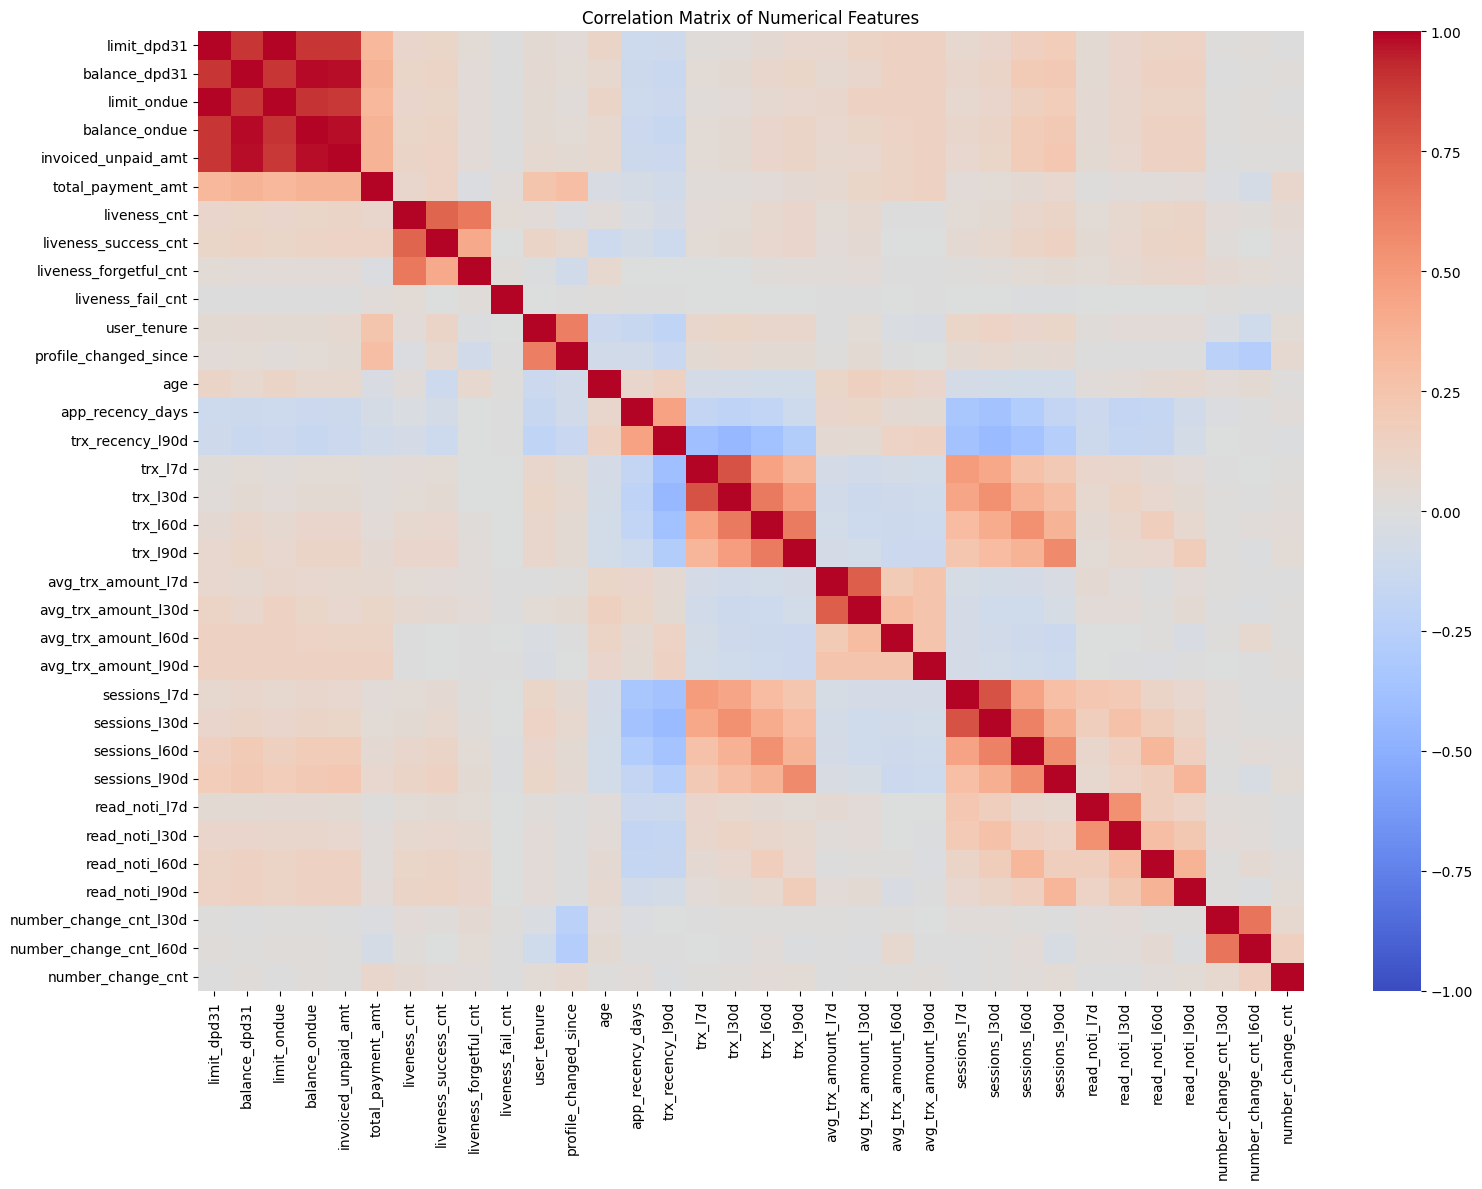

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

## 3.5 Feature Correlation Analysis

Numerical features-ийн хоорондын correlation-ийг шинжилж,
хоорондоо өндөр хамааралтай feature-үүд болон potential redundancy-г
тодорхойлсон. Энэ нь model development-ийн өмнө давхардсан мэдээлэлтэй
feature-үүдийг илрүүлэхэд ашиглагдана.